# Wambaza — Multilingual ASRH Question Answering
## Model Notebook: Data Analysis, Model Architecture & Performance

**Project:** Wambaza — "You can ask me" — Multilingual AI-powered ASRH guidance platform for Rwanda and Uganda

**Dataset:** HASH Multilingual Health QA Challenge (Zindi / ITU, 2026)

**Languages:** English · Luganda · Kinyarwanda (extension)

**Model:** mT5-base fine-tuned with LoRA + LangChain RAG pipeline

**Author:** Diane Pretty Ntakirutimana

**Date:** June 2026


## 1. Install and Import Packages

In [1]:
# Verify all key packages installed correctly
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import torch
import transformers
import peft

print('pandas      :', pd.__version__)
print('numpy       :', np.__version__)
print('torch       :', torch.__version__)
print('transformers:', transformers.__version__)
print('peft        :', peft.__version__)
print('sklearn     :', sklearn.__version__)

pandas      : 2.2.2
numpy       : 2.0.2
torch       : 2.11.0+cu128
transformers: 5.10.2
peft        : 0.19.1
sklearn     : 1.6.1


# 2. Importing dependencies

In [2]:
import warnings
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 120)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot style configuration
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [20]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = Path('/content/drive/MyDrive/Multilingual data')

# Load all splits
train_all = pd.read_csv(DATA_DIR / 'Train.csv')
val_all   = pd.read_csv(DATA_DIR / 'Val.csv')
test_all  = pd.read_csv(DATA_DIR / 'Test.csv')

# Filtering to English and Luganda only
TARGET_SUBSETS = ['Eng_Uga', 'Eng_Gha', 'Eng_Eth', 'Eng_Ken', 'Lug_Uga']

train = train_all[train_all['subset'].isin(TARGET_SUBSETS)].reset_index(drop=True).copy()
val   = val_all[val_all['subset'].isin(TARGET_SUBSETS)].reset_index(drop=True).copy()
test  = test_all[test_all['subset'].isin(TARGET_SUBSETS)].reset_index(drop=True).copy()

print(f'  Training set   : {len(train):,} rows')
print(f'  Validation set : {len(val):,} rows')
print(f'  Test set       : {len(test):,} rows')
print()
print('  Target languages: English · Luganda')
print('  Kinyarwanda    : to be added via translation pipeline')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Training set   : 21,445 rows
  Validation set : 4,592 rows
  Test set       : 1,836 rows

  Target languages: English · Luganda
  Kinyarwanda    : to be added via translation pipeline



# 5. Displaying data of each substet

**Language codes**

* **Eng_Eth:** English questions collected in Ethiopia
* **Eng_Gha:** English questions collected in Ghana
* **Eng_Ken:** English questions collected in Kenya
* **Lug_Uga:** Luganda questions collected in Uganda

In [21]:
# ── Dataset samples ───────────────────────────────────────────
print('=' * 60)
print('  TRAINING SET — Sample (5 rows)')
print('=' * 60)
display(train[['ID', 'input', 'output', 'subset']].sample(5, random_state=42))

print()
print('=' * 60)
print('  VALIDATION SET — Sample (5 rows)')
print('=' * 60)
display(val[['ID', 'input', 'output', 'subset']].sample(5, random_state=42))

print()
print('=' * 60)
print('  TEST SET — Sample (5 rows)')
print('  Note: No output column — model must generate answers')
print('=' * 60)
display(test[['ID', 'input', 'subset']].sample(5, random_state=42))

  TRAINING SET — Sample (5 rows)


,ID,input,output,subset
7449,ID_TR_Eng_Gha_81DEC9DB,How can counseling help me navigate sexual relationships and make informed decisions about sexual health?,Counseling can help adolescents navigate sexual relationships and make informed decisions about sexual health by pro...,Eng_Gha
5382,ID_TR_Eng_Gha_CA12BA49,"What are the legal consequences for perpetrators of alcohol and drug-facilitated assaults, and how can adolescents a...",The legal consequences for perpetrators of alcohol and drug-facilitated assaults vary depending on the jurisdiction ...,Eng_Gha
1215,ID_TR_Eng_Eth_2D90E4EE,What do health workers say about can herpes stop marriage?,"This is a question about, Herpes. Herpes cannot be cured but medicines reduce outbreaks and spread. It can be preven...",Eng_Eth
1911,ID_TR_Eng_Eth_AB6EF8DD,Is it wrong to desire to travel or live in a big city for a better life?,"This is a question about, Culture/Aspiration. No. It is a natural desire to seek a better life. Plan responsibly (ge...",Eng_Eth
12400,ID_TR_Eng_Uga_2700260B,What should I do if I feel unsafe in a relationship?,Trust your feelings and talk to someone you trust while considering ways to get safe.,Eng_Uga



  VALIDATION SET — Sample (5 rows)


,ID,input,output,subset
3201,ID_VL_Eng_Uga_C5C9FB91,"How do I test for trichomoniasis?, please answer this using simple medical terms.",1. Microscopic examination using a wet mount: 2. Culture Test3. Nucleic Acid Amplification Test...,Eng_Uga
2820,ID_VL_Eng_Uga_D9A09007,"Different types of Human Immunodeficiency Virus?, please answer in detail.",There are two different types of HIV. These are called HIV-1 and HIV-2 which are distinct at a genetic level.Overall...,Eng_Uga
1616,ID_VL_Eng_Gha_01539221,"What are the long-term consequences of bullying, and how can it impact my future relationships and mental health?","The long-term consequences of bullying can be significant and may impact various areas of your life, including your ...",Eng_Gha
2696,ID_VL_Eng_Uga_C1BCBE59,I want to know how to satisfy my husband.,Satisfying your sexual partner will be different for different people. It is important first of all to keep communic...,Eng_Uga
4080,ID_VL_Lug_Uga_4E329B4B,Mitendera ki gy'olina okuyitamu bw'okizuula nti olina Akawuka akaleeta Siriimu?,"Bw’oba ozuuliddwa nti olina Akawuka akaleeta Siriimu, kikulu okukola emitendera egiwerako egy’amangu okukakasa nti o...",Lug_Uga



  TEST SET — Sample (5 rows)
  Note: No output column — model must generate answers


,ID,input,subset
614,ID_TS_Eng_Ken_98C7472A,How can HIV affect my mental health?,Eng_Ken
1473,ID_TS_Lug_Uga_44777442,Nnyinza ntya okwekebeza Obuwuka obuleeta Obulwadde bw'Ekikaba?,Lug_Uga
1564,ID_TS_Lug_Uga_1EB74B56,Akawuka akaleeta Siriimu kasobola okujjanjabibwa?,Lug_Uga
1696,ID_TS_Lug_Uga_97674900,Kisoboka omuntu okuwona Akawuka akaleeta Siriimu/Siriimu ng’akozesa ARVs okumala ebbanga eddene?,Lug_Uga
855,ID_TS_Eng_Uga_D7665CDA,"Explain Neisseria Gonorrhoeae Infection to me., please answer this using simple medical terms.",Eng_Uga


#6. Data quality check


In [28]:
# ── Data quality check ────────────────────────────────────────
print('=' * 50)
print('  DATA QUALITY REPORT')
print('=' * 50)

for name, df in [('Training', train), ('Validation', val.copy()), ('Test', test.copy())]:
    print(f'\n  {name} Set:')
    print(f'    Missing values : {df.isnull().sum().sum()}')
    print(f'    Duplicate rows : {df.duplicated().sum()}')
    print(f'    Total rows     : {len(df):,}')

print()
print('=' * 50)

# Check question lengths
train['q_len'] = train['input'].str.split().str.len()
val['q_len']   = val['input'].str.split().str.len()

# Check answer lengths (train and val only — test has no answers)
train['a_len'] = train['output'].str.split().str.len()
val['a_len']   = val['output'].str.split().str.len()

# Empty questions
empty_q_train = train[train['q_len'] == 0]
empty_q_val   = val[val['q_len'] == 0]

# Empty answers
empty_a_train = train[train['a_len'] == 0]
empty_a_val   = val[val['a_len'] == 0]

print(f'\n  Empty questions — train : {len(empty_q_train)}')
print(f'  Empty questions — val   : {len(empty_q_val)}')
print(f'  Empty answers   — train : {len(empty_a_train)}')
print(f'  Empty answers   — val   : {len(empty_a_val)}')

# Drop any rows with empty questions or answers
before = len(train)
train = train[(train['q_len'] > 0) & (train['a_len'] > 0)].reset_index(drop=True)
after = len(train)

print(f'\n  Rows dropped : {before - after}')
print(f'  Final training rows : {after:,}')
print()

  DATA QUALITY REPORT

  Training Set:
    Missing values : 0
    Duplicate rows : 0
    Total rows     : 21,444

  Validation Set:
    Missing values : 0
    Duplicate rows : 0
    Total rows     : 4,592

  Test Set:
    Missing values : 0
    Duplicate rows : 0
    Total rows     : 1,836


  Empty questions — train : 0
  Empty questions — val   : 0
  Empty answers   — train : 0
  Empty answers   — val   : 0

  Rows dropped : 0
  Final training rows : 21,444



# 7. Feature engineering

In [29]:
# ── Feature engineering ───────────────────────────────────────

# Simplified language labels — merge all English subsets into one
LANG_MAP = {
    'Eng_Uga': 'English',
    'Eng_Gha': 'English',
    'Eng_Eth': 'English',
    'Eng_Ken': 'English',
    'Lug_Uga': 'Luganda',
    'Kin_Rwa': 'Kinyarwanda',  # will be added after translation
}

train['language'] = train['subset'].map(LANG_MAP)
val['language']   = val['subset'].map(LANG_MAP)

# ── Language distribution ─────────────────────────────────────
print('=' * 45)
print('     LANGUAGE DISTRIBUTION (TRAIN)')
print('=' * 45)
lang_counts = train['language'].value_counts()
total = len(train)
for lang, count in lang_counts.items():
    pct = count / total * 100
    bar = '█' * int(pct / 2)
    print(f'  {lang:<15} {count:>6,} rows  ({pct:.1f}%)  {bar}')
print(f'  {"TOTAL":<15} {total:>6,} rows')
print()

# ── Question length summary ───────────────────────────────────
print('=' * 45)
print('     QUESTION LENGTH SUMMARY (words)')
print('=' * 45)
q = train['q_len']
print(f'  Average   : {q.mean():.1f} words')
print(f'  Median    : {q.median():.0f} words')
print(f'  Shortest  : {q.min():.0f} words')
print(f'  Longest   : {q.max():.0f} words')
print(f'  Variation : {q.std():.1f} words')
print()

# ── Answer length summary ─────────────────────────────────────
print('=' * 45)
print('     ANSWER LENGTH SUMMARY (words)')
print('=' * 45)
a = train['a_len']
print(f'  Average   : {a.mean():.1f} words')
print(f'  Median    : {a.median():.0f} words')
print(f'  Shortest  : {a.min():.0f} words')
print(f'  Longest   : {a.max():.0f} words')
print(f'  Variation : {a.std():.1f} words')
print()

# ── Q vs A ratio ──────────────────────────────────────────────
print('=' * 45)
print('     QUESTION vs ANSWER RATIO')
print('=' * 45)
ratio = a.mean() / q.mean()
print(f'  For every 1 word in a question,')
print(f'  the answer contains ~{ratio:.0f} words.')
print(f'  Short questions require long detailed answers.')
print()

     LANGUAGE DISTRIBUTION (TRAIN)
  English         18,061 rows  (84.2%)  ██████████████████████████████████████████
  Luganda          3,383 rows  (15.8%)  ███████
  TOTAL           21,444 rows

     QUESTION LENGTH SUMMARY (words)
  Average   : 13.2 words
  Median    : 12 words
  Shortest  : 1 words
  Longest   : 55 words
  Variation : 6.1 words

     ANSWER LENGTH SUMMARY (words)
  Average   : 74.1 words
  Median    : 59 words
  Shortest  : 1 words
  Longest   : 482 words
  Variation : 57.8 words

     QUESTION vs ANSWER RATIO
  For every 1 word in a question,
  the answer contains ~6 words.
  Short questions require long detailed answers.



# 8. Language distribution

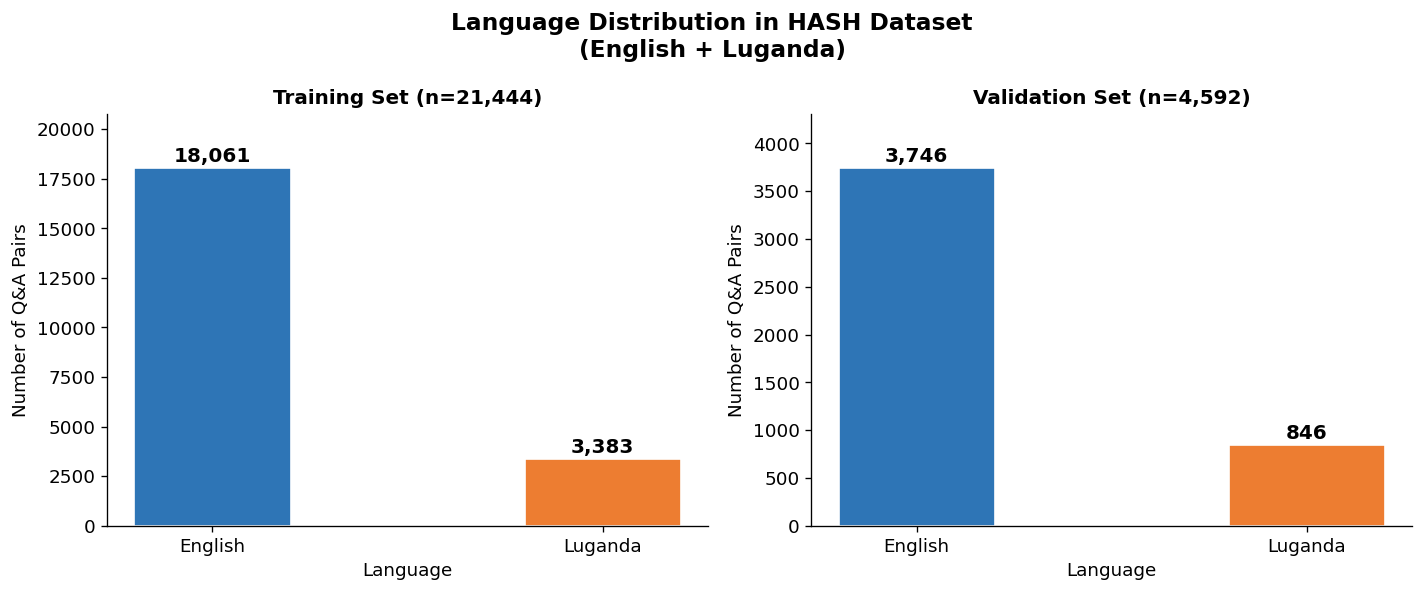

language_distribution.png saved.


In [35]:
# ── Visualization 1: Language distribution bar chart ──────────
COLORS = ['#2E75B6', '#ED7D31']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Language Distribution in HASH Dataset\n(English + Luganda)',
             fontsize=14, fontweight='bold')

# Training set
train_counts = train.groupby('language').size().sort_values(ascending=False)
bars1 = axes[0].bar(train_counts.index, train_counts.values,
                    color=COLORS[:len(train_counts)], edgecolor='white', width=0.4)
axes[0].set_title('Training Set (n=21,444)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Q&A Pairs', fontsize=11)
axes[0].set_xlabel('Language', fontsize=11)
for bar, count in zip(bars1, train_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_ylim(0, max(train_counts.values) * 1.15)

# Validation set
val_counts = val.groupby('language').size().sort_values(ascending=False)
bars2 = axes[1].bar(val_counts.index, val_counts.values,
                    color=COLORS[:len(val_counts)], edgecolor='white', width=0.4)
axes[1].set_title('Validation Set (n=4,592)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Q&A Pairs', fontsize=11)
axes[1].set_xlabel('Language', fontsize=11)
for bar, count in zip(bars2, val_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{count:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, max(val_counts.values) * 1.15)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Multilingual data/Plots/language_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('language_distribution.png saved.')

# 9. Question length distribution
The question length distribution is consistent across both training and validation
sets, with most questions falling between 8 and 18 words and peaking around 12 to
13 words. This reflects the short, conversational nature of adolescent health queries
such as "How do I test for HIV?" The mean (13.2 words) is slightly above the median
(12 words), indicating a small number of longer questions with formatting instructions
pulling the average up.

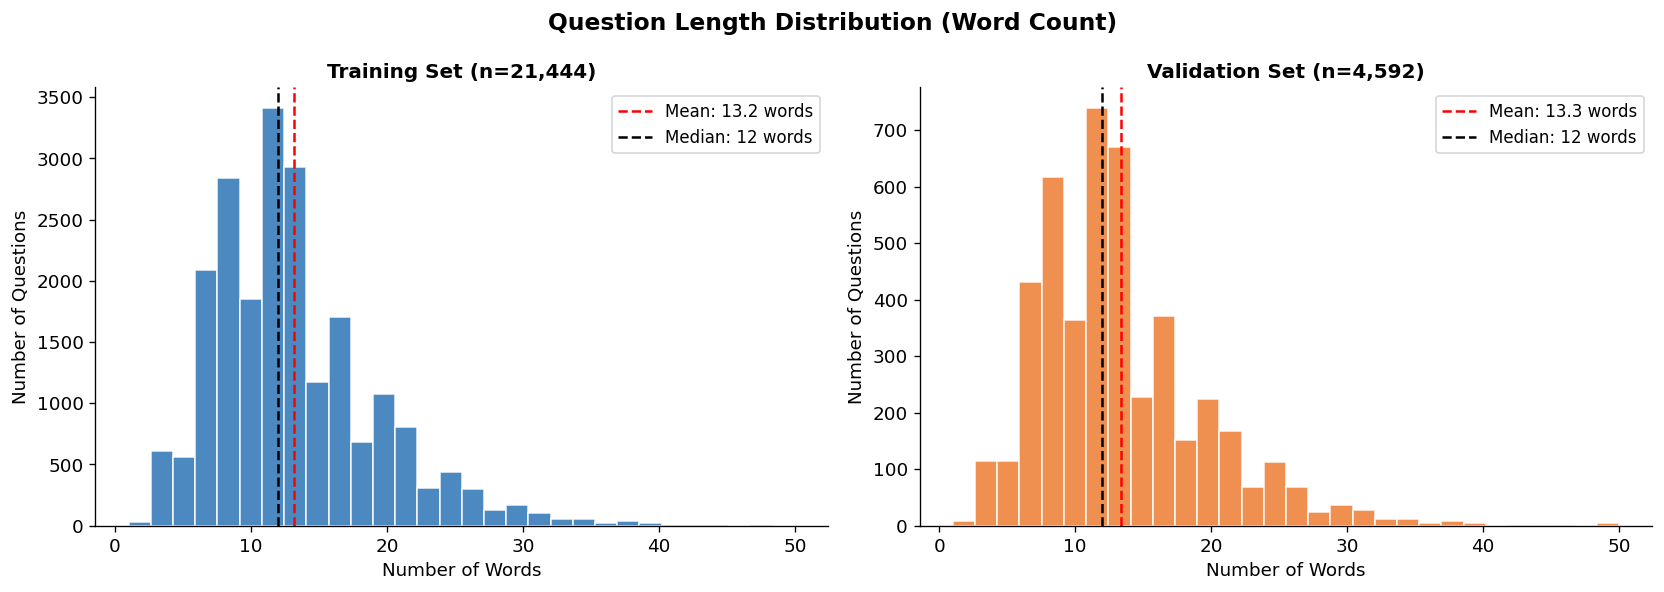


Question_length.png saved.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Question Length Distribution (Word Count)',
             fontsize=14, fontweight='bold')

for ax, df, title, color in [
    (axes[0], train, 'Training Set (n=21,444)', '#2E75B6'),
    (axes[1], val,   'Validation Set (n=4,592)', '#ED7D31')
]:
    ax.hist(df['q_len'].clip(upper=50), bins=30,
            color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df['q_len'].mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean: {df["q_len"].mean():.1f} words')
    ax.axvline(df['q_len'].median(), color='black', linestyle='--',
               linewidth=1.5, label=f'Median: {df["q_len"].median():.0f} words')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Words', fontsize=11)
    ax.set_ylabel('Number of Questions', fontsize=11)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Multilingual data/Plots/Question_length.png',
            dpi=150, bbox_inches='tight')
plt.show()
print()
print('Question_length.png saved.')

# 10. Answer length distribution
Unlike questions, answers vary widely in length — ranging from just 1 word to
482 words, with most answers falling between 20 and 100 words. The mean (74 words)
is noticeably higher than the median (59 words), indicating that a number of very
long answers are pulling the average up. This wide variation makes sense for an
ASRH platform where some questions require a simple one-line response while others
demand detailed medical explanations.

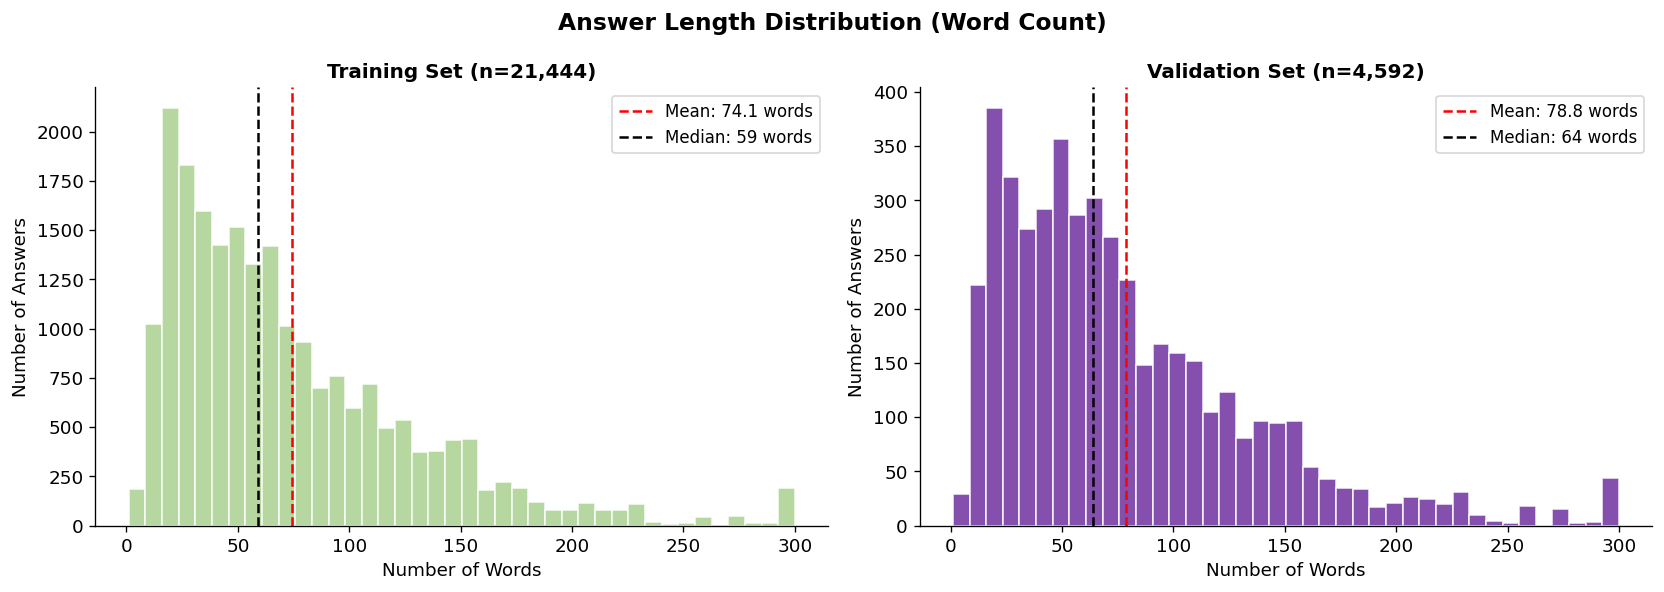

Answer_length.png saved


In [40]:
# ── Visualization 3: Answer length distribution ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Answer Length Distribution (Word Count)',
             fontsize=14, fontweight='bold')

for ax, df, title, color in [
    (axes[0], train, 'Training Set (n=21,444)', '#A9D18E'),
    (axes[1], val,   'Validation Set (n=4,592)', '#7030A0')
]:
    ax.hist(df['a_len'].clip(upper=300), bins=40,
            color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df['a_len'].mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean: {df["a_len"].mean():.1f} words')
    ax.axvline(df['a_len'].median(), color='black', linestyle='--',
               linewidth=1.5, label=f'Median: {df["a_len"].median():.0f} words')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Number of Words', fontsize=11)
    ax.set_ylabel('Number of Answers', fontsize=11)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Multilingual data/Plots/answer_length.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Answer_length.png saved')